# Phase 5A: Superposition Metric (Elhage et al.)

Measure how densely SAE features are packed using the feature dimensionality
metric from "Toy Models of Superposition" (Elhage et al., 2022):

$$D_i = \frac{1}{1 + \sum_{j \neq i} \cos^2(W_i, W_j)}$$

- $D_i = 1.0$: feature $i$ is perfectly orthogonal to all others (full dimension)
- $D_i \to 0$: heavy superposition (feature shares its direction with many others)
- $\text{total\_D} = \sum_i D_i$: effective number of independent dimensions

**Key question**: Does STP use more or less superposition than NTP?
Higher total_D = less superposition = features are more orthogonal.

In [1]:
from phase5_superposition import (
    feature_dimensionality,
    random_baseline_dimensionality,
    plot_dimensionality_distribution,
    plot_dimensionality_summary,
    print_dimensionality_report,
)
from sae_analysis import load_sae

SAE_PATHS = {
    "NTP": "/home/jay/repos/llm-jepa/trained_saes/ntp_layer15",
    "STP": "/home/jay/repos/llm-jepa/trained_saes/stp_layer15",
}
DEVICE = "cuda"
CHUNK_SIZE = 512

## Load SAEs

In [2]:
saes = {}
for name, path in SAE_PATHS.items():
    print(f"Loading {name} SAE from {path}")
    saes[name] = load_sae(path, device=DEVICE)
    print(f"  W_dec shape: {saes[name].W_dec.shape}")

Loading NTP SAE from /home/jay/repos/llm-jepa/trained_saes/ntp_layer15
  W_dec shape: torch.Size([16384, 2048])
Loading STP SAE from /home/jay/repos/llm-jepa/trained_saes/stp_layer15
  W_dec shape: torch.Size([16384, 2048])


/home/jay/miniconda3/envs/jepa/lib/python3.14/site-packages/sae_lens/saes/sae.py:251: UserWarning: 
This SAE has non-empty model_from_pretrained_kwargs. 
For optimal performance, load the model like so:
model = HookedSAETransformer.from_pretrained_no_processing(..., **cfg.model_from_pretrained_kwargs)
  warnings.warn(


## Compute Feature Dimensionality

For each feature $i$, compute $D_i$ from the decoder weight interference.
This is chunked to avoid materializing the full 16384x16384 pairwise matrix.

In [3]:
results = {}
for name, sae in saes.items():
    print(f"\n{name}:")
    D, total_D = feature_dimensionality(sae, chunk_size=CHUNK_SIZE, device=DEVICE)
    results[name] = {"D": D, "total_D": total_D}


NTP:
  d_sae=16384, d_model=2048
  total_D = 430.8 / 16384 (0.0263 per feature)
  D_i: mean=0.0263, median=0.0241, min=0.0015, max=0.1464

STP:
  d_sae=16384, d_model=2048
  total_D = 565.4 / 16384 (0.0345 per feature)
  D_i: mean=0.0345, median=0.0330, min=0.0051, max=0.1310


## Random Baseline

Compute expected total_D for random unit vectors in the same dimensions.
This controls for the geometric fact that random vectors in $\mathbb{R}^{2048}$
have nonzero expected $\cos^2 \approx 1/d_{\text{model}}$.

In [4]:
d_sae = saes["NTP"].W_dec.shape[0]
d_model = saes["NTP"].W_dec.shape[1]
print(f"Computing random baseline: {d_sae} vectors in R^{d_model}")

baseline_mean, baseline_std, baseline_per_feature = random_baseline_dimensionality(
    d_sae, d_model, n_samples=5, chunk_size=CHUNK_SIZE, device=DEVICE
)
print(f"\nRandom baseline: total_D = {baseline_mean:.1f} +/- {baseline_std:.1f}")

Computing random baseline: 16384 vectors in R^2048
  Random sample 1/5: total_D = 1820.6
  Random sample 2/5: total_D = 1820.8
  Random sample 3/5: total_D = 1820.7
  Random sample 4/5: total_D = 1821.0
  Random sample 5/5: total_D = 1820.7

Random baseline: total_D = 1820.7 +/- 0.1


## Results

In [5]:
print_dimensionality_report(results, baseline_mean, baseline_std)


Feature Dimensionality Report (Elhage et al.)

  NTP:
    total_D       = 430.8 / 16384
    normalized    = 0.2366 (vs random baseline)
    D_i mean      = 0.0263
    D_i median    = 0.0241
    D_i std       = 0.0175
    D_i min       = 0.0015
    D_i max       = 0.1464

  STP:
    total_D       = 565.4 / 16384
    normalized    = 0.3105 (vs random baseline)
    D_i mean      = 0.0345
    D_i median    = 0.0330
    D_i std       = 0.0151
    D_i min       = 0.0051
    D_i max       = 0.1310

  Random baseline:
    total_D       = 1820.7 +/- 0.1

  Ratio NTP/STP = 0.7620
  Difference = -134.6


## Distribution of D_i

Overlaid histograms of per-feature dimensionality. If STP has a heavier tail
of high-D features, its representations are less superposed.

Saved: phase5_distribution.png


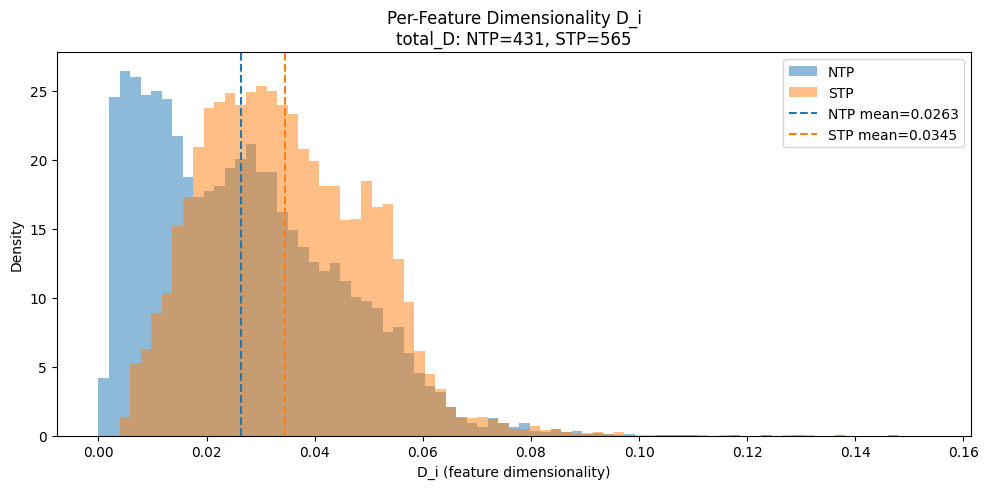

In [ ]:
plot_dimensionality_distribution(
    results["NTP"]["D"], results["STP"]["D"],
    save_path="phase5_distribution.png",

    
)

interpretation: x axis is each feature. If a feature is at 0, that feature's direction is nearly collinear with many others, no independent dimension. X=1 means it's orthogonal to everything else. So here we see that STP makes features less dense and superimposed. NTP is more spread

## Summary

Saved: phase5_summary.png


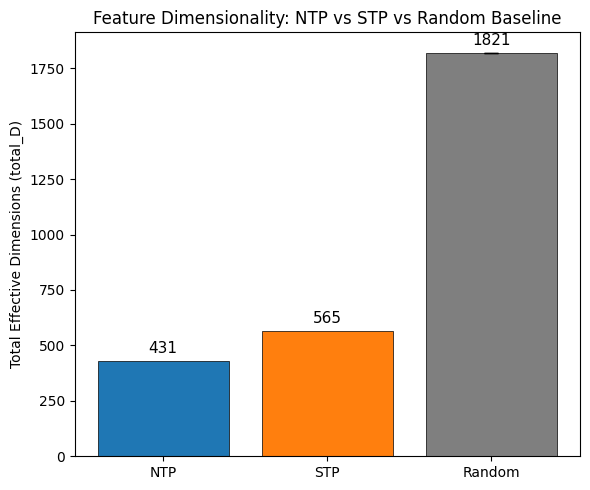

In [7]:
plot_dimensionality_summary(
    results, baseline_mean, baseline_std,
    save_path="phase5_summary.png",
)

## Interpretation

Key numbers:
- **total_D**: effective independent dimensions used by each SAE
- **normalized total_D**: ratio vs random baseline (>1 = more orthogonal than random, <1 = more superposed)
- **NTP/STP ratio**: >1 means NTP uses less superposition, <1 means STP does